In [1]:
# Import required packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

# Model Evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Plotly visualisation
import plotly.graph_objects as go
from math import pi

# Data Pre-processing

## Traffic Data

In [2]:
# Load traffic data
traffic_df_original = pd.read_excel('laei-2019-major-roads-vkm-flows-speeds.xlsx')

In [3]:
# Create copy (development purposes so we don't have to reload excel spreadsheet)
traffic_df = traffic_df_original.copy()

In [4]:
# Clean up column names
traffic_df.columns = [
    x.strip().lower().replace('-','')\
    .replace('  ','_').replace(' ','_')\
    .replace('(','').replace(')','')\
    .replace('/','_').replace('_2019','')\
    for x in traffic_df.columns
]

In [5]:
# Convert all columns to numbers, except for the first 5
columns_to_convert = list(traffic_df.columns[5:])
traffic_df[columns_to_convert] = traffic_df[columns_to_convert].apply(
    lambda col: pd.to_numeric(col, errors='coerce')
)

In [6]:
# Sum similar vehicle types to map with major roads data

# Group and sum all HGV Rigid types for AADT
aadt_hgvs_rigid_columns = [
    'aadt_hgvs_rigid_2_axles',
    'aadt_hgvs_rigid_3_axles',
    'aadt_hgvs_rigid_4_or_more_axles'
]
traffic_df['aadt_hgvs_rigid'] = traffic_df[aadt_hgvs_rigid_columns].sum(axis=1)

# Group and sum all HGV Articulated types for AADT
aadt_hgvs_articulated_columns = [
    'aadt_hgvs_articulated_3_to_4_axles',
    'aadt_hgvs_articulated_5_axles',
    'aadt_hgvs_articulated_6_axles'
]
traffic_df['aadt_hgvs_articulated'] = traffic_df[aadt_hgvs_articulated_columns].sum(axis=1)

# Group and sum all HGV Rigid types for VKM
vkm_hgvs_rigid_columns = [
    'vkm_hgvs_rigid_2_axles',
    'vkm_hgvs_rigid_3_axles',
    'vkm_hgvs_rigid_4_or_more_axles'
]
traffic_df['vkm_hgvs_rigid'] = traffic_df[vkm_hgvs_rigid_columns].sum(axis=1)

# Group and sum all HGV Articulated types for VKM
vkm_hgvs_articulated_columns = [
    'vkm_hgvs_articulated_3_to_4_axles',
    'vkm_hgvs_articulated_5_axles',
    'vkm_hgvs_articulated_6_axles'
]
traffic_df['vkm_hgvs_articulated'] = traffic_df[vkm_hgvs_articulated_columns].sum(axis=1)

In [7]:
# List-wise removal of original VKM and AADT columns (before group and sum)
aadt_and_vkm_columns = aadt_hgvs_rigid_columns + aadt_hgvs_articulated_columns + vkm_hgvs_rigid_columns + vkm_hgvs_articulated_columns
traffic_df = traffic_df.drop(aadt_and_vkm_columns, axis=1)

In [8]:
# List-wise removal of:
#    * year (no predictive value, e.g. all values are the same)
#    * aadt_total and vkm_total (cannot be transposed to merge with major roads dataset)
traffic_df = traffic_df.drop(['year', 'aadt_total', 'vkm_total'], axis=1)

In [9]:
# Define column renaming dictionaries @TODO Review mapping of coaches (aadt_coaches and vkm_coaches)!
aadt_rename_dict = {
    'aadt_motorcycle': 'road_motorcycle',
    'aadt_taxi': 'road_taxi',
    'aadt_petrol_car': 'road_car_petrol',
    'aadt_diesel_car': 'road_car_diesel',
    'aadt_electric_car': 'road_car_electric',
    'aadt_petrol_phv': 'road_phv_petrol',
    'aadt_diesel_phv': 'road_phv_diesel',
    'aadt_electric_phv': 'road_phv_electric',
    'aadt_petrol_lgv': 'road_lgv_petrol',
    'aadt_diesel_lgv': 'road_lgv_diesel',
    'aadt_electric_lgv': 'road_lgv_electric',
    'aadt_hgvs_rigid': 'road_hgv_rigid',
    'aadt_hgvs_articulated': 'road_hgv_articulated',
    'aadt_buses': 'road_tfl_bus',
    'aadt_coaches': 'road_non_tfl_bus_or_coach',
}

vkm_rename_dict = {
    'vkm_motorcycle': 'road_motorcycle',
    'vkm_taxi': 'road_taxi',
    'vkm_petrol_car': 'road_car_petrol',
    'vkm_diesel_car': 'road_car_diesel',
    'vkm_electric_car': 'road_car_electric',
    'vkm_petrol_phv': 'road_phv_petrol',
    'vkm_diesel_phv': 'road_phv_diesel',
    'vkm_electric_phv': 'road_phv_electric',
    'vkm_petrol_lgv': 'road_lgv_petrol',
    'vkm_diesel_lgv': 'road_lgv_diesel',
    'vkm_electric_lgv': 'road_lgv_electric',
    'vkm_hgvs_rigid': 'road_hgv_rigid',
    'vkm_hgvs_articulated': 'road_hgv_articulated',
    'vkm_buses': 'road_tfl_bus',
    'vkm_coaches': 'road_non_tfl_bus_or_coach',
}

In [10]:
# Split dataframe into three categories (toid will persist among all of them):
#    * road_df - location, speeds, link lengths
#    * aadt_df - all AADT vehicular information
#    * vkm_df - all VKM vehicular information

road_df = traffic_df[[
    'toid',
    'laei_zone',
    'borough',
    'road_classification',
    'speed_km_hr_except_buses',
    'speed_km_hr_buses_only',
    'link_length_m',
]]

aadt_df = traffic_df[['toid'] + list(aadt_rename_dict.keys())]

vkm_df = traffic_df[['toid'] + list(vkm_rename_dict.keys())]

In [11]:
# Rename columns to match major roads
aadt_df = aadt_df.rename(columns=aadt_rename_dict)
vkm_df = vkm_df.rename(columns=vkm_rename_dict)

## Major Roads Link Emissions

In [12]:
# Load major links excel file (Detailed Road Transport)
xl = pd.ExcelFile('LAEI2019-nox-pm-co2-major-roads-link-emissions.xlsx')

In [13]:
# Create dataframe for each road link emissions worksheet
original_nox_df = xl.parse('NOx Road Link Emissions')
original_pm10_df = xl.parse('PM10 Road Link Emissions')
original_pm25_df = xl.parse('PM2.5 Road Link Emissions')
original_co2_df = xl.parse('CO2 Road Link Emissions')

In [14]:
# Create copies (this is for development purposes, as loading worksheets take long)
nox_df = original_nox_df.copy()
pm10_df = original_pm10_df.copy()
pm25_df = original_pm25_df.copy()
co2_df = original_co2_df.copy()

In [15]:
# Drop and standardise column names
df_list = [nox_df, pm10_df, pm25_df, co2_df]
for df in df_list:
    # list-wise removal of 2025 and 2030 forecasts
    columns_to_drop = []
    for column in df.columns:
        if '2025' in column or '2030' in column:
            columns_to_drop.append(column)
    df.drop(columns=columns_to_drop, axis=1, inplace=True)
    
    # standardise column names to conform to snake_case convention
    df.columns = [x.strip().lower().replace('-','_').replace('_2019','') for x in df.columns]

In [16]:
# Drop pm-source for pm10 and pm2.5 dataframes
pm10_df = pm10_df.drop('pm_source', axis=1)
pm25_df = pm25_df.drop('pm_source', axis=1)

In [17]:
# Group by TOID and sum pollutant (there were duplicate TOIDs since there was a record for each pm-source)
pm10_df = pm10_df.groupby('toid', as_index=False).sum(numeric_only=True)
pm25_df = pm25_df.groupby('toid', as_index=False).sum(numeric_only=True)

## Merging Traffic Data and Major Roads Link Emissions

In [18]:
# Construct dictionary of dataframes containing vehicle data
vehicle_dict = {
    "nox": nox_df,
    "pm10": pm10_df,
    "pm25": pm25_df,
    "co2": co2_df,
    "vkm": vkm_df,
    "aadt": aadt_df,
}

In [19]:
# Transform each dataframe
for key, df in vehicle_dict.items():
    df_melted = df.melt(
        id_vars = ['toid'],
        value_vars = [
            'road_car_petrol',
            'road_car_diesel',
            'road_car_electric',
            'road_phv_petrol',
            'road_phv_diesel',
            'road_phv_electric',
            'road_lgv_petrol',
            'road_lgv_diesel',
            'road_lgv_electric',
            'road_hgv_rigid',
            'road_hgv_articulated',
            'road_tfl_bus',
            'road_non_tfl_bus_or_coach',
            'road_taxi',
            'road_motorcycle',
        ],
        var_name = 'vehicle',
        value_name = f'{key}',
    )
    vehicle_dict[key] = df_melted

In [20]:
# Create merged dataframe
merged_df = vehicle_dict['nox']\
.merge(vehicle_dict['pm10'], on=['toid', 'vehicle'])\
.merge(vehicle_dict['pm25'], on=['toid', 'vehicle'])\
.merge(vehicle_dict['co2'], on=['toid', 'vehicle'])\
.merge(vehicle_dict['vkm'], on=['toid', 'vehicle'])\
.merge(vehicle_dict['aadt'], on=['toid', 'vehicle'])

In [21]:
# Merge traffic data
new_merged_df = pd.merge(merged_df, road_df, on='toid', how='left')

In [22]:
# Reorder columns
new_merged_df = new_merged_df[[
    'toid',
    'borough',
    'laei_zone',
    'road_classification',
    'vehicle',
    'speed_km_hr_except_buses',
    'speed_km_hr_buses_only',
    'link_length_m',
    'nox',
    'pm10',
    'pm25',
    'co2',
    'vkm',
    'aadt',
]]

In [23]:
# Merge bus & non-bus speeds by associating bus speeds with bus types, and non-bus speeds with other vehicle types
new_merged_df['speed'] = new_merged_df.apply(
    lambda row: row['speed_km_hr_buses_only']
    if row['vehicle'] == 'road_tfl_bus'
    else row['speed_km_hr_except_buses'], axis=1
)

## Data Cleaning
### List-wise removal of unnecessary columns
### Pair-wise removal of missing and inaccurate data 

In [24]:
# Set df to merged_df
df = new_merged_df

<Axes: >

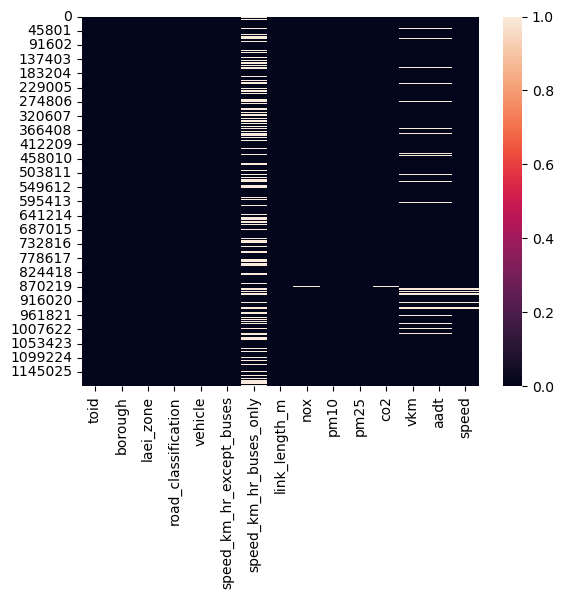

In [25]:
# Display heatmap of missing values
sns.heatmap(df.isnull())

In [26]:
# List-wise removal of original bus & non-bus speed columns
df = df.drop(['speed_km_hr_buses_only', 'speed_km_hr_except_buses'], axis=1)

In [27]:
# Review missing value counts
df.isna().sum()

toid                       0
borough                    0
laei_zone                  0
road_classification        0
vehicle                    0
link_length_m              0
nox                       98
pm10                       0
pm25                       0
co2                       98
vkm                    65073
aadt                   65073
speed                  26979
dtype: int64

In [28]:
# Pair-wise removal of records where nox and co2 are NaN
df = df.dropna(subset=['nox', 'co2'], how='all')

In [29]:
# Review missing value counts (only columns with more than 0 missing values)
df.isna().sum()[df.isna().sum() > 0]

vkm      65073
aadt     65073
speed    26979
dtype: int64

In [30]:
# Found records with missing VKM, AADT and Speeed
df.loc[
    (df['vkm'].isnull()) &
    (df['aadt'].isnull()) &
    (df['speed'].isnull())
].head(1)

,toid,borough,laei_zone,road_classification,vehicle,link_length_m,nox,pm10,pm25,co2,vkm,aadt,speed
873268,osgb4000000027865913,Non-GLA,Non-GLA,M1,road_tfl_bus,2371,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [31]:
# Pair-wise removal of above.
df = df.loc[
    ~(
        (df['vkm'].isnull()) &
        (df['aadt'].isnull()) &
        (df['speed'].isnull())
    )
]

In [32]:
# Review missing value counts (only columns with more than 0 missing values)
df.isna().sum()[df.isna().sum() > 0]

vkm      39663
aadt     39663
speed     1569
dtype: int64

In [33]:
# Found records where VKM and AADT are NaN, emissions are 0, but speed is greater than 0.
# Note: Recorded speeds without traffic data suggests data inaccuracy, and should be removed.
df.loc[
    (df['co2'] == 0.0) &
    (df['nox'] == 0.0) &
    (df['pm10'] == 0.0) &
    (df['pm25'] == 0.0) &
    (df['aadt'].isnull()) &
    (df['vkm'].isnull()) &
    (df['speed'] > 0)
].head(1)

,toid,borough,laei_zone,road_classification,vehicle,link_length_m,nox,pm10,pm25,co2,vkm,aadt,speed
288,osgb4000000027909025,Non-GLA,Non-GLA,M1,road_car_petrol,77,0.0,0.0,0.0,0.0,NaN,NaN,32.0


In [34]:
# Pair-wise removal of records identified above.
df = df.loc[
    ~(
        (df['co2'] == 0.0) &
        (df['nox'] == 0.0) &
        (df['pm10'] == 0.0) &
        (df['pm25'] == 0.0) &
        (df['aadt'].isnull()) &
        (df['vkm'].isnull()) &
        (df['speed'] > 0)
    )
]

In [35]:
# Review missing value counts
df.isna().sum()[df.isna().sum() > 0]

vkm       193
aadt      193
speed    1569
dtype: int64

In [36]:
# Found records where VKM and AADT are greater than 0, but emissions are all 0.
# Note: This suggests data inaccuracy because if there is traffic, there should be emissions. 
df.loc[
    (df['co2'] == 0.0) &
    (df['nox'] == 0.0) &
    (df['pm10'] == 0.0) &
    (df['pm25'] == 0.0) &
    (df['aadt'] > 0.0) &
    (df['vkm'] > 0.0)
].head(1)

,toid,borough,laei_zone,road_classification,vehicle,link_length_m,nox,pm10,pm25,co2,vkm,aadt,speed
873460,osgb4000000027887298,Non-GLA,Non-GLA,A Road,road_tfl_bus,212,0.0,0.0,0.0,0.0,4875.0,63.0,NaN


In [37]:
# Pair-wise removal of above.
df = df.loc[
    ~(
        (df['co2'] == 0.0) &
        (df['nox'] == 0.0) &
        (df['pm10'] == 0.0) &
        (df['pm25'] == 0.0) &
        (df['aadt'] > 0.0) &
        (df['vkm'] > 0.0)
    )
]

In [38]:
# Review missing value counts (only columns with more than 0 missing values)
df.isna().sum()[df.isna().sum() > 0]

vkm      193
aadt     193
speed      7
dtype: int64

In [39]:
# There exists only 200 records with NaN values between VKM, AADT and Speed.
# This is a small portion of the data, and can be removed.
df[
    (
        (df['vkm'].isnull()) |
        (df['aadt'].isnull()) |
        (df['speed'].isnull())
    )
].shape[0]

200

In [40]:
# Pair-wise removal of remaining records containing missing values.
df = df.dropna(subset=['vkm', 'aadt', 'speed'], how='any')

In [41]:
# Review missing value counts
# Data set now contains no missing data
df.isna().sum()

toid                   0
borough                0
laei_zone              0
road_classification    0
vehicle                0
link_length_m          0
nox                    0
pm10                   0
pm25                   0
co2                    0
vkm                    0
aadt                   0
speed                  0
dtype: int64

In [42]:
# PCA identified that these features are not valuable, and therefore should be removed. 
df = df.drop(['toid', 'borough', 'laei_zone'], axis=1)

In [43]:
# Save a copy of cleaned data (for development purposes)
cleaned_df = df

In [44]:
# Define sample size and sample dataframe
SAMPLE_SIZE = 100000

if SAMPLE_SIZE > 0:
    df = cleaned_df.sample(SAMPLE_SIZE)
else:
    df = cleaned_df

print(df.shape)

(100000, 10)


In [45]:
# Review data
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 155447 to 958891
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   road_classification  100000 non-null  object 
 1   vehicle              100000 non-null  object 
 2   link_length_m        100000 non-null  int64  
 3   nox                  100000 non-null  float64
 4   pm10                 100000 non-null  float64
 5   pm25                 100000 non-null  float64
 6   co2                  100000 non-null  float64
 7   vkm                  100000 non-null  float64
 8   aadt                 100000 non-null  float64
 9   speed                100000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 8.4+ MB


In [46]:
# Consider number of unique values in type object/string
df[['road_classification', 'vehicle']].nunique()

road_classification    12
vehicle                15
dtype: int64

In [47]:
# Review data shape
df.shape

(100000, 10)

In [48]:
# Create new dataframe (features)
df1 = df[[
    'road_classification',
    'vehicle',
    'speed',
    'link_length_m',
    'vkm',
    'aadt',
]]

In [49]:
# Review new features DataFrame
df1.head(1)

,road_classification,vehicle,speed,link_length_m,vkm,aadt
155447,A Road,road_car_diesel,23.0,17,15555.0,2478.0


In [50]:
# Review full DataFrame
df.head(1)

,road_classification,vehicle,link_length_m,nox,pm10,pm25,co2,vkm,aadt,speed
155447,A Road,road_car_diesel,17,0.010592,0.001009,0.000541,2.708031,15555.0,2478.0,23.0


## OneHotEncoding of Categorical Features

In [51]:
# Apply OneHotEncoder to transform catagorical features

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['road_classification', 'vehicle']
one_hot = OneHotEncoder()
column_transformer = ColumnTransformer([('one_hot', one_hot, categorical_features)], remainder='passthrough')
tf_X = column_transformer.fit_transform(df1)
tf_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 596579 stored elements and shape (100000, 31)>

In [52]:
# Create DataFrame from arrays

tf_X_df = pd.DataFrame(tf_X.toarray())
tf_X_df.head(1)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,23.0,17.0,15555.0,2478.0


In [53]:
# Reapply original feature names after OneHotEncoding

remaining_columns = df1.columns.drop(categorical_features)
new_column_names = column_transformer.named_transformers_['one_hot'].get_feature_names_out(categorical_features).tolist() + remaining_columns.tolist()

In [54]:
new_column_names

['road_classification_A Road',
 'road_classification_A1M',
 'road_classification_B Road',
 'road_classification_C / Unclassified Road',
 'road_classification_M1',
 'road_classification_M11',
 'road_classification_M20',
 'road_classification_M23',
 'road_classification_M25',
 'road_classification_M3',
 'road_classification_M4',
 'road_classification_M40',
 'vehicle_road_car_diesel',
 'vehicle_road_car_electric',
 'vehicle_road_car_petrol',
 'vehicle_road_hgv_articulated',
 'vehicle_road_hgv_rigid',
 'vehicle_road_lgv_diesel',
 'vehicle_road_lgv_electric',
 'vehicle_road_lgv_petrol',
 'vehicle_road_motorcycle',
 'vehicle_road_non_tfl_bus_or_coach',
 'vehicle_road_phv_diesel',
 'vehicle_road_phv_electric',
 'vehicle_road_phv_petrol',
 'vehicle_road_taxi',
 'vehicle_road_tfl_bus',
 'speed',
 'link_length_m',
 'vkm',
 'aadt']

In [55]:
# Assign the new column names to the DataFrame, and inspect new DataFrame
tf_X_df.columns = new_column_names
tf_X_df.head(1)

,road_classification_A Road,road_classification_A1M,road_classification_B Road,road_classification_C / Unclassified Road,road_classification_M1,road_classification_M11,road_classification_M20,road_classification_M23,road_classification_M25,road_classification_M3,...,vehicle_road_non_tfl_bus_or_coach,vehicle_road_phv_diesel,vehicle_road_phv_electric,vehicle_road_phv_petrol,vehicle_road_taxi,vehicle_road_tfl_bus,speed,link_length_m,vkm,aadt
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,23.0,17.0,15555.0,2478.0


## Normalisation of quantitative features

In [56]:
# Standardise features with quantitative values

from sklearn.preprocessing import StandardScaler

cols_to_norm = ['speed','link_length_m', 'vkm', 'aadt']
tf_X_df[cols_to_norm] = StandardScaler().fit_transform(tf_X_df[cols_to_norm])

In [57]:
tf_X_df.describe()

,road_classification_A Road,road_classification_A1M,road_classification_B Road,road_classification_C / Unclassified Road,road_classification_M1,road_classification_M11,road_classification_M20,road_classification_M23,road_classification_M25,road_classification_M3,...,vehicle_road_non_tfl_bus_or_coach,vehicle_road_phv_diesel,vehicle_road_phv_electric,vehicle_road_phv_petrol,vehicle_road_taxi,vehicle_road_tfl_bus,speed,link_length_m,vkm,aadt
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05
mean,0.507160,0.000080,0.136030,0.339500,0.001610,0.001350,0.000180,0.000500,0.011090,0.000600,...,0.058050,0.066690,0.066460,0.065690,0.06938,0.045510,-2.891909e-17,-3.680611e-17,4.050094e-18,-1.769251e-17
std,0.499951,0.008944,0.342822,0.473542,0.040093,0.036718,0.013415,0.022355,0.104724,0.024488,...,0.233839,0.249486,0.249086,0.247741,0.25410,0.208421,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-1.759404e+00,-6.048131e-01,-1.123527e-01,-4.092377e-01
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-5.513593e-01,-4.517835e-01,-1.115803e-01,-4.010562e-01
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-2.334527e-01,-2.834511e-01,-1.069724e-01,-3.572609e-01
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,3.387790e-01,6.851682e-02,-8.043117e-02,-1.623476e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,5.679608e+00,2.823360e+01,8.703417e+01,2.046766e+01


In [58]:
tf_X_df.head(1)

,road_classification_A Road,road_classification_A1M,road_classification_B Road,road_classification_C / Unclassified Road,road_classification_M1,road_classification_M11,road_classification_M20,road_classification_M23,road_classification_M25,road_classification_M3,...,vehicle_road_non_tfl_bus_or_coach,vehicle_road_phv_diesel,vehicle_road_phv_electric,vehicle_road_phv_petrol,vehicle_road_taxi,vehicle_road_tfl_bus,speed,link_length_m,vkm,aadt
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.360615,-0.482389,-0.061446,0.783343


In [59]:
# Display correlation

tf_X_df.corr()

,road_classification_A Road,road_classification_A1M,road_classification_B Road,road_classification_C / Unclassified Road,road_classification_M1,road_classification_M11,road_classification_M20,road_classification_M23,road_classification_M25,road_classification_M3,...,vehicle_road_non_tfl_bus_or_coach,vehicle_road_phv_diesel,vehicle_road_phv_electric,vehicle_road_phv_petrol,vehicle_road_taxi,vehicle_road_tfl_bus,speed,link_length_m,vkm,aadt
road_classification_A Road,1.000000,-0.009074,-0.402520,-0.727282,-0.040736,-0.037298,-0.013611,-0.022689,-0.107425,-0.024856,...,0.026939,-0.004830,-0.001252,-0.000528,0.003647,0.033869,0.110919,-0.049269,0.005393,0.130801
road_classification_A1M,-0.009074,1.000000,-0.003549,-0.006413,-0.000359,-0.000329,-0.000120,-0.000200,-0.000947,-0.000219,...,-0.002220,-0.002391,0.002102,-0.002372,0.001958,-0.001953,0.027911,0.002700,0.006498,0.016511
road_classification_B Road,-0.402520,-0.003549,1.000000,-0.284480,-0.015934,-0.014589,-0.005324,-0.008875,-0.042020,-0.009722,...,-0.000331,-0.001074,-0.001529,-0.004896,-0.003992,0.004049,0.022611,-0.033219,-0.022337,-0.039335
road_classification_C / Unclassified Road,-0.727282,-0.006413,-0.284480,1.000000,-0.028790,-0.026360,-0.009620,-0.016035,-0.075923,-0.017567,...,-0.028880,0.004222,0.000312,0.002542,-0.000869,-0.030808,-0.265773,-0.019457,-0.053525,-0.147215
road_classification_M1,-0.040736,-0.000359,-0.015934,-0.028790,1.000000,-0.001476,-0.000539,-0.000898,-0.004253,-0.000984,...,0.002831,0.005262,0.002303,-0.000580,0.000815,-0.008769,0.179787,0.099419,0.049564,0.031597
road_classification_M11,-0.037298,-0.000329,-0.014589,-0.026360,-0.001476,1.000000,-0.000493,-0.000822,-0.003894,-0.000901,...,0.001355,0.001088,0.002217,0.001244,0.000679,-0.008028,0.136198,0.071300,0.031277,0.018941
road_classification_M20,-0.013611,-0.000120,-0.005324,-0.009620,-0.000539,-0.000493,1.000000,-0.000300,-0.001421,-0.000329,...,-0.003331,0.002389,0.011383,-0.000549,0.002204,-0.002930,0.059287,0.006686,-0.000518,-0.002102
road_classification_M23,-0.022689,-0.000200,-0.008875,-0.016035,-0.000898,-0.000822,-0.000300,1.000000,-0.002369,-0.000548,...,0.002099,0.004779,0.001216,-0.000514,-0.002586,-0.004884,0.092077,0.024485,0.002644,0.001538
road_classification_M25,-0.107425,-0.000947,-0.042020,-0.075923,-0.004253,-0.003894,-0.001421,-0.002369,1.000000,-0.002595,...,0.001888,0.001164,0.003947,0.008537,0.000022,-0.023124,0.382775,0.316796,0.239636,0.131784
road_classification_M3,-0.024856,-0.000219,-0.009722,-0.017567,-0.000984,-0.000901,-0.000329,-0.000548,-0.002595,1.000000,...,-0.000844,0.004908,0.003299,0.000097,-0.001869,-0.005350,0.097334,0.070768,0.025133,0.010822


<Axes: >

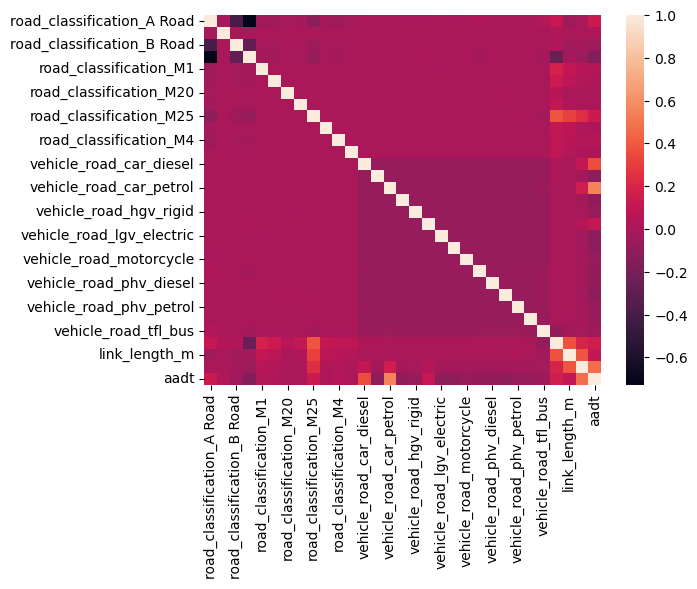

In [60]:
# Display correlation matrix

sns.heatmap(tf_X_df.corr())

## Principle Component Analysis for feature reduction

In [61]:
# Apply PCA to reduce number of features (standardisation applied before)

from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit(tf_X_df)

In [62]:
X_pca.explained_variance_ratio_

array([3.37742642e-01, 1.90517878e-01, 1.33782592e-01, 7.66343349e-02,
       6.57102791e-02, 3.09494994e-02, 1.27964500e-02, 1.27196411e-02,
       1.26382160e-02, 1.25744652e-02, 1.25618038e-02, 1.25320244e-02,
       1.25173545e-02, 1.24857841e-02, 1.21589589e-02, 1.20132242e-02,
       1.18869701e-02, 1.06149726e-02, 8.33036176e-03, 5.44737126e-03,
       2.03321138e-03, 4.79890104e-04, 2.89228607e-04, 2.55921946e-04,
       1.25561463e-04, 9.57686266e-05, 5.51279477e-05, 3.49196171e-05,
       1.55464639e-05, 0.00000000e+00, 0.00000000e+00])

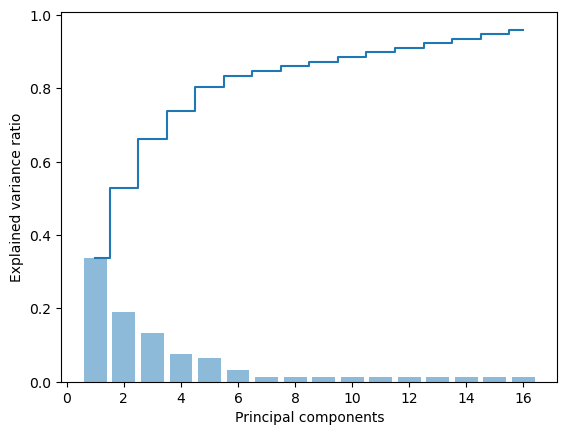

In [63]:
# Apply PCA to reduce the number of features (standardisation applied before)
# Also help with problem of multicollinearity

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
X_pca = pca.fit_transform(tf_X_df)


# access explained_variance_ratio_ from pca object and slice to 16 components
plt.bar(
    range(1, 17),
    pca.explained_variance_ratio_[:16],
    alpha=0.5,
    align='center'
)
plt.step(range(1, 17), np.cumsum(pca.explained_variance_ratio_[:16]), where='mid') # access explained_variance_ratio_ from pca object and slice to 16 components
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.show()


<BarContainer object of 16 artists>

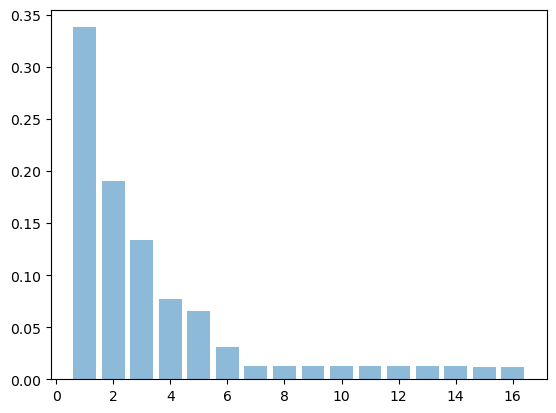

In [64]:
plt.bar(
    range(1, 17),
    pca.explained_variance_ratio_[:16], # access explained_variance_ratio_ from pca object and slice to 16 components
    alpha=0.5,
    align='center'
)

In [65]:
pca2 = PCA(n_components=6)
X_pca2 = pca2.fit_transform(tf_X_df)
X_pca2.shape

(100000, 6)

In [66]:
X_pca2

array([[ 0.00605114,  0.96666786,  0.49409908, -0.31131568,  0.45386926,
        -0.07200403],
       [-0.39375892,  0.01723898,  0.17993013,  0.22752498,  0.61716176,
        -0.0966697 ],
       [ 0.5931965 ,  1.36450761,  0.85797685, -0.66522113,  0.28686052,
        -0.08039017],
       ...,
       [ 0.2360723 ,  0.00692666,  0.74920837,  0.10955715,  0.35304672,
        -0.14297721],
       [-0.43774395,  0.24620757,  0.05439565,  0.11561991,  0.64799338,
        -0.07934146],
       [ 0.46675459, -1.10941774,  0.23402187,  0.10041349, -0.35495572,
         0.96880336]])

In [67]:
features = pd.DataFrame(X_pca2)

In [68]:
features.shape

(100000, 6)

## Model training

In [69]:
# Define X and y

# Input features
X = features

# Function to return y output series depending on pollutant
def get_y(pollutant):
    return df[pollutant]

In [70]:
# Get X and y training and testing datasets

# Define random state to ensure reproducability of training and testing sets
RANDOM_STATE = 42

# Get train and test split for X
X_train, X_test = train_test_split(X, test_size=0.2, random_state=RANDOM_STATE)

# Define function to return train and test splits for y based on pollutant
def get_y_train_test_split(pollutant):
    y = get_y(pollutant)
    y_train, y_test = train_test_split(y, test_size=0.2, random_state=RANDOM_STATE)
    return y_train, y_test

In [71]:
# Define function to return model instance depending on input string
def create_model(algorithm: str):
    if algorithm == 'linear_regression':
        return LinearRegression()
    elif algorithm == 'decision_tree':
        return DecisionTreeRegressor()
    elif algorithm == 'random_forest':
        return RandomForestRegressor(n_jobs=-1)
    elif algorithm == 'svr':
        return SVR()
    elif algorithm == 'xgb_regressor':
        return XGBRegressor()
    elif algorithm == 'ridge_regressor':
        return Ridge()

In [72]:
# Define a function to return a dictionary to store trained models for each pollutant
def create_model_collection(pollutants):
    collection = dict()
    for p in pollutants:
        collection[p] = dict()
    return collection

In [73]:
# Define function to return dictionary to store evaulation results
def create_results_template(pollutants, algorithms, evaluators):
    results_template = {}
    for pol in pollutants:
        results_template[pol] = {}
        for alg in algorithms:
            results_template[pol][alg] = {}
            for eva in evaluators:
                results_template[pol][alg][eva] = float()
    return results_template

In [74]:
# Define list of pollutants
pollutants = ['co2', 'nox', 'pm10', 'pm25']

# Define list of algorithms to train for each pollutant
algorithms = ['decision_tree', 'random_forest', 'xgb_regressor', 'ridge_regressor']

# Define list of evaluators used to evaluate trained models
evaluators = ['MAE', 'MSE', 'RMSE', 'R2', 'PROCESSING_TIME_IN_SECONDS']

### Basic models (default parameters) are iteratively trained and evaluated for each pollutant, algorithm, and evaluator defined above

In [75]:
%%time

# Train models
np.random.seed(42)

# Validation for SVR (SVR is computationally expensive for large datasets)
if SAMPLE_SIZE > 10000 and 'svr' in algorithms:
    raise ValueError("Execution stopped: SVR was selected, and sample size is greater than 10000.")

# Create dictionary to store trained models
model_collection = create_model_collection(pollutants)

# Create structure to store all results
model_results = create_results_template(pollutants, algorithms, evaluators)

# Iteratively train all models for each pollutant
for pollutant, model_dict in model_collection.items():
    # Get train and test data for y
    y_train, y_test = get_y_train_test_split(pollutant)

    # Store y Series for future usage
    for algorithm in algorithms:
        # Record start time for computation time evaluation
        start_time = time.time()
        
        # Train model and store in model_collection dictionary
        model_collection[pollutant][algorithm] = create_model(algorithm).fit(X_train, y_train)

        # Record end time after training model
        end_time = time.time() - start_time
        
        # Create model predictions
        predictions = model_collection[pollutant][algorithm].predict(X_test)

        # Evaluate model
        mae = mean_absolute_error(y_test, predictions)
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, predictions)

        # Store evaluations
        model_results[pollutant][algorithm]['MAE'] = mae
        model_results[pollutant][algorithm]['MSE'] = mse
        model_results[pollutant][algorithm]['RMSE'] = rmse
        model_results[pollutant][algorithm]['R2'] = r2
        model_results[pollutant][algorithm]['PROCESSING_TIME_IN_SECONDS'] = end_time


CPU times: user 4min 47s, sys: 708 ms, total: 4min 48s
Wall time: 28.7 s


In [76]:
# Function to convert results dictionary into a DataFrame
def results_to_dataframe(results_template, evaluation_keys):
    flat_data = []

    for pollutant, models in results_template.items():
        for model, evaluation in models.items():
            # Build row for each evaluation
            row = {
                'Pollutant': pollutant,
                'Model': model,
            }
            for key in evaluation_keys:
                row[key] = evaluation.get(key)
            flat_data.append(row)
    
    df = pd.DataFrame(flat_data)
    return df

results_df = results_to_dataframe(model_results, evaluators)

In [77]:
# Review results
results_df

,Pollutant,Model,MAE,MSE,RMSE,R2,PROCESSING_TIME_IN_SECONDS
0,co2,decision_tree,3.259321,501.161088,22.386627,0.803007,0.881782
1,co2,random_forest,2.611746,274.796614,16.576991,0.891985,6.288565
2,co2,xgb_regressor,3.353284,770.235368,27.753115,0.697241,0.079580
3,co2,ridge_regressor,4.856845,493.705978,22.219495,0.805937,0.004653
4,nox,decision_tree,0.012258,0.006473,0.080453,0.761998,0.862055
5,nox,random_forest,0.010287,0.003996,0.063215,0.853059,6.358046
6,nox,xgb_regressor,0.011654,0.007494,0.086567,0.724450,0.080595
7,nox,ridge_regressor,0.018299,0.015590,0.124862,0.426734,0.004654
8,pm10,decision_tree,0.000767,0.000024,0.004942,0.696404,0.812822
9,pm10,random_forest,0.000570,0.000007,0.002713,0.908517,5.969349


([0, 1, 2, 3],
 [Text(0, 0, 'random_forest'),
  Text(1, 0, 'xgb_regressor'),
  Text(2, 0, 'ridge_regressor'),
  Text(3, 0, 'decision_tree')])

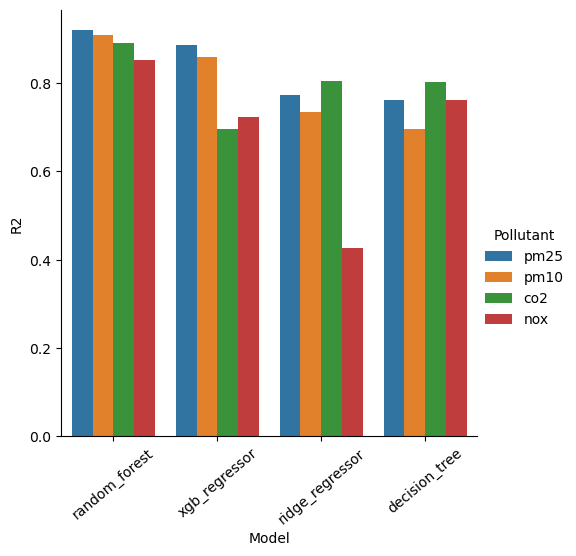

In [78]:
# Filter R2 scores and plot
r2_scores = results_df[['Pollutant', 'Model', 'R2']].sort_values(by='R2', ascending=False)

# Remove negatives
r2_scores = r2_scores[r2_scores['R2'] > 0]
sns.catplot(
    data=r2_scores,
    x='Model',
    y='R2',
    hue='Pollutant',
    kind='bar',
    height=5,
    aspect=1
)
plt.xticks(rotation=40)

In [79]:
# Cross validation for all pollutants and models
algorithms_to_cross_validate = ['random_forest']
cv = 5
result_list = []
for x in range(1,cv+1):
    result_list.append('split_{}'.format(x))

cv_results = create_results_template(pollutants, algorithms_to_cross_validate, result_list)

# Here, y refers to the output series used to train the respective model
for pollutant in model_collection.keys():
    y = get_y(pollutant)
    for algorithm in algorithms_to_cross_validate:
        cross_validation_scores = cross_val_score(
            model_collection[pollutant][algorithm],
            X,
            y,
            cv=cv
        )
        for i in range(0, len(cross_validation_scores)):
            cv_results[pollutant][algorithm]['split_{}'.format(i+1)]= cross_validation_scores[i]


cross_validation_df = results_to_dataframe(cv_results, result_list)
cross_validation_df['average_cross_validation_score'] = cross_validation_df[result_list].mean(axis=1)

In [80]:
cross_validation_df

,Pollutant,Model,split_1,split_2,split_3,split_4,split_5,average_cross_validation_score
0,co2,random_forest,0.758690,0.858214,0.885751,0.728225,0.706908,0.787557
1,nox,random_forest,0.639617,0.726162,0.751357,0.819058,0.413262,0.669891
2,pm10,random_forest,0.863688,0.881275,0.892671,0.907229,0.868440,0.882661
3,pm25,random_forest,0.867887,0.887085,0.911831,0.919063,0.842237,0.885621


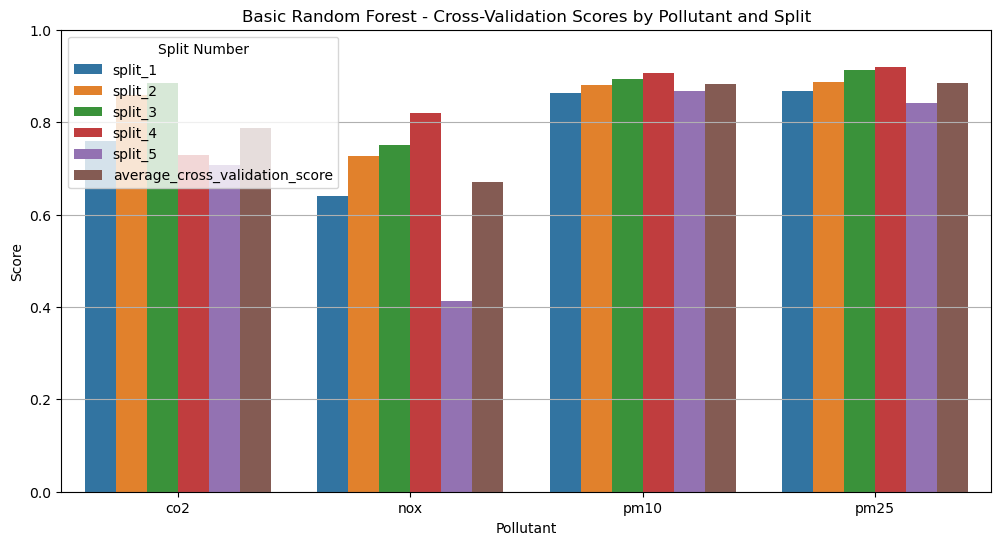

In [81]:
# Catplot of basic random forest cross validation
basic_rf_cv_results = cross_validation_df[['Pollutant', 'Model', 'split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'average_cross_validation_score']]

# Reshaping the DataFrame to long format
basic_rf_cv_results_melted = pd.melt(
    basic_rf_cv_results,
    id_vars=['Pollutant', 'Model'],
    value_vars=['split_1', 'split_2', 'split_3', 'split_4', 'split_5', 'average_cross_validation_score'],
    var_name='Split Number',
    value_name='Score'
)

basic_rf_cv_results_melted.head()

# Creating the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=basic_rf_cv_results_melted, x='Pollutant', y='Score', hue='Split Number')

# Adding titles and labels
plt.title('Basic Random Forest - Cross-Validation Scores by Pollutant and Split')
plt.xlabel('Pollutant')
plt.ylabel('Score')
plt.legend(title='Split Number')
plt.ylim(0, 1)  # Adjust based on your score range
plt.grid(axis='y')

# Show the plot
plt.show()

([0], [Text(0, 0, 'random_forest')])

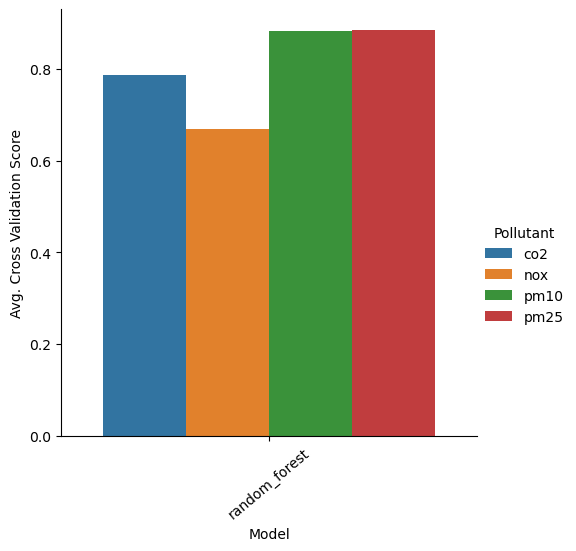

In [82]:
# Catplot of cross validation scores

# Remove negative values
cross_validation_df = cross_validation_df[cross_validation_df['average_cross_validation_score'] > 0]

cv_catplot = sns.catplot(
    data=cross_validation_df,
    x='Model',
    y='average_cross_validation_score',
    hue='Pollutant',
    kind='bar',
    height=5,
    aspect=1
)
cv_catplot.set(ylabel='Avg. Cross Validation Score')
plt.xticks(rotation=40)

In [83]:
# Review Train v Test score

def results_train_test(pollutant, model):
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    y_train, y_test = get_y_train_test_split(pollutant)
    scores = {
        'Training MAE': mean_absolute_error(y_train, train_preds),
        'Test MAE': mean_absolute_error(y_test, test_preds),
        'Training MSE': mean_squared_error(y_train, train_preds),
        'Test MSE': mean_squared_error(y_test, test_preds),
        'Training RMSE': np.sqrt(mean_squared_error(y_train, train_preds)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_preds)),
        'Training R2': r2_score(y_train, train_preds),
        'Test R2': r2_score(y_test, test_preds)
    }
    return scores


## Parameter tuning on Random Forest

### Parameter tuning with RandomizedSearchCV

In [84]:
%%time
# Improve Random Forest with Hyperparameter Tuning using RandomizedSearchCV

np.random.seed(42)

# Dictionary to store results
hypter_tuned_rf_results = create_results_template(pollutants, ['random_forest_randomised_search'], evaluators)

#Random Forest

ran_grid = {
    'n_estimators': np.arange(10, 100, 10),
    'max_depth': [None, 3, 5, 10],
    'min_samples_split': np.arange(2, 20, 2),
    'min_samples_leaf': np.arange(1, 20, 2),
    'max_features': [0.5, 1, 'sqrt'],
    'bootstrap': [True, False]
}

hypertuned_rf_collection = dict()

for pollutant in pollutants:
    y_train, y_test = get_y_train_test_split(pollutant)
    ran_reg_hyper_model = RandomizedSearchCV(
        RandomForestRegressor(
            n_jobs=-1,
            random_state=42
        ),
        param_distributions=ran_grid,
        n_iter=10,
        cv=5,
        verbose=True
    )
    
    # Start time
    start_time = time.time()

    # Fit model
    hypertuned_rf_collection[pollutant] = ran_reg_hyper_model.fit(X_train, y_train)

    # End time
    end_time = time.time() - start_time

    # Create predictions
    predictions = hypertuned_rf_collection[pollutant].predict(X_test)
    
    # Evaluate model
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    # Store evaluations
    hypter_tuned_rf_results[pollutant]['random_forest_randomised_search']['MAE'] = mae
    hypter_tuned_rf_results[pollutant]['random_forest_randomised_search']['MSE'] = mse
    hypter_tuned_rf_results[pollutant]['random_forest_randomised_search']['RMSE'] = rmse
    hypter_tuned_rf_results[pollutant]['random_forest_randomised_search']['R2'] = r2
    hypter_tuned_rf_results[pollutant]['random_forest_randomised_search']['PROCESSING_TIME_IN_SECONDS'] = end_time

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Fitting 5 folds for each of 10 candidates, totalling 50 fits
CPU times: user 18min 53s, sys: 1.61 s, total: 18min 55s
Wall time: 1min 51s


### Parameter tuning with GridSearchCV (For CO2 only because it is an exhaustive approach and hence computationally intensive)

In [85]:
%%time
# Improve Random Forest with Hyperparameter Tuning using GridSearchCV

np.random.seed(42)

single_pollutant = "co2"

# Dictionary to store results
rf_results_grid_search = create_results_template(
    [single_pollutant],
    ['random_forest_grid_search'],
    evaluators
)

grid_search_parameters = {
    'n_estimators':[40, 60, 80],
    'max_depth': [None],
    'min_samples_split': [12],
    'min_samples_leaf': [1,2],
    'max_features': ['sqrt', 'log2'],
    # 'max_samples': [10000]
}

y_train, y_test = get_y_train_test_split(single_pollutant)
ran_reg_hyper_model = GridSearchCV(
    RandomForestRegressor(
        n_jobs=-1,
        random_state=42
    ),
    param_grid=grid_search_parameters,
    cv=5,
    verbose=True
)

# Start time
start_time = time.time()

# Fit model
rf_grid_search_model = ran_reg_hyper_model.fit(X_train, y_train)

# End time
end_time = time.time() - start_time

# Create predictions
predictions = rf_grid_search_model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

# Store evaluations
rf_results_grid_search[single_pollutant]['random_forest_grid_search']['MAE'] = mae
rf_results_grid_search[single_pollutant]['random_forest_grid_search']['MSE'] = mse
rf_results_grid_search[single_pollutant]['random_forest_grid_search']['RMSE'] = rmse
rf_results_grid_search[single_pollutant]['random_forest_grid_search']['R2'] = r2
rf_results_grid_search[single_pollutant]['random_forest_grid_search']['PROCESSING_TIME_IN_SECONDS'] = end_time

grid_search_rf_results_df = results_to_dataframe(rf_results_grid_search, evaluators)
grid_search_rf_results_df.head()

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/lib/python3.12/site-packages/numpy/ma/core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


CPU times: user 13min 18s, sys: 649 ms, total: 13min 19s
Wall time: 1min 13s


,Pollutant,Model,MAE,MSE,RMSE,R2,PROCESSING_TIME_IN_SECONDS
0,co2,random_forest_grid_search,2.845036,282.992131,16.82237,0.888763,73.794799


## Final results and interpration

In [86]:
# Join hyperparameter tuned Random Forest results with results of basic models
hypter_tuned_rf_results_df = results_to_dataframe(hypter_tuned_rf_results, evaluators)
joined_results_df = pd.concat([results_df, hypter_tuned_rf_results_df, grid_search_rf_results_df], ignore_index=True)
joined_results_df
joined_results_df.sort_values(by='R2', ascending=False)

,Pollutant,Model,MAE,MSE,RMSE,R2,PROCESSING_TIME_IN_SECONDS
13,pm25,random_forest,0.000302,0.000002,0.001419,0.920463,5.999188
9,pm10,random_forest,0.000570,0.000007,0.002713,0.908517,5.969349
19,pm25,random_forest_randomised_search,0.000345,0.000002,0.001548,0.905348,29.304231
1,co2,random_forest,2.611746,274.796614,16.576991,0.891985,6.288565
20,co2,random_forest_grid_search,2.845036,282.992131,16.822370,0.888763,73.794799
14,pm25,xgb_regressor,0.000361,0.000003,0.001689,0.887333,0.064937
18,pm10,random_forest_randomised_search,0.000638,0.000009,0.003029,0.885935,25.551571
16,co2,random_forest_randomised_search,2.662815,290.429067,17.041980,0.885840,36.690436
10,pm10,xgb_regressor,0.000689,0.000011,0.003355,0.860068,0.082526
5,nox,random_forest,0.010287,0.003996,0.063215,0.853059,6.358046


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'random_forest'),
  Text(1, 0, 'random_forest_randomised_search'),
  Text(2, 0, 'random_forest_grid_search'),
  Text(3, 0, 'xgb_regressor'),
  Text(4, 0, 'ridge_regressor'),
  Text(5, 0, 'decision_tree')])

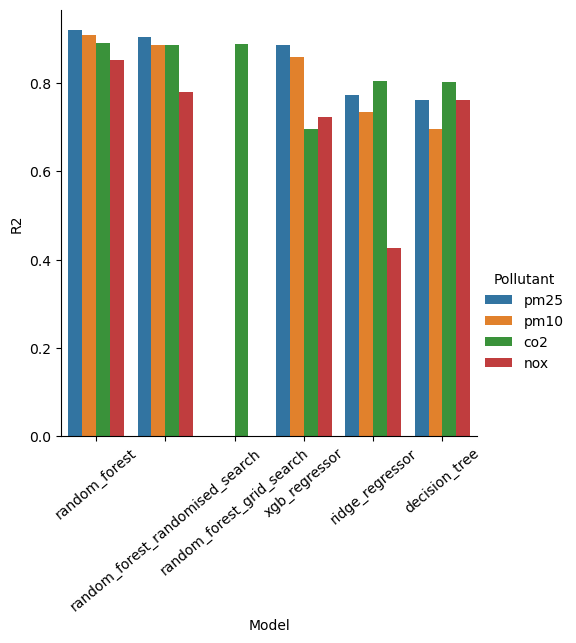

In [87]:
# Plot R2 results, including Hyptertuned Random Forest for comparison

# Filter R2 scores and plot
r2_scores = joined_results_df[['Pollutant', 'Model', 'R2']].sort_values(by='R2', ascending=False)

# Remove records where R2 is negative
r2_scores = r2_scores[r2_scores['R2'] > 0]

# Plot R2 scores
sns.catplot(
    data=r2_scores,
    x='Model',
    y='R2',
    hue='Pollutant',
    kind='bar',
    height=5,
    aspect=1
)
plt.xticks(rotation=40)

In [88]:
# Demonstrate that best parameters differ for models trained on different output labels
best_fit_records = []
for pollutant, trained_model in hypertuned_rf_collection.items():
    best_params = trained_model.best_params_
    best_params['pollutant'] = pollutant
    best_fit_records.append(best_params)
    
best_fit_df = pd.DataFrame(data=best_fit_records)
best_fit_df[['pollutant', 'bootstrap', 'n_estimators', 'min_samples_split', 'min_samples_leaf', 'max_features', 'max_depth']]

,pollutant,bootstrap,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth
0,co2,False,60,6,1,sqrt,NaN
1,nox,True,30,8,5,0.5,5.0
2,pm10,True,10,8,5,0.5,NaN
3,pm25,False,80,6,1,1,NaN


In [89]:
# Get model results for test/train comparison, for each pollutant and corresponding trained model
test_train_results = dict()
for pollutant, trained_model in hypertuned_rf_collection.items():
    test_train_results[pollutant] = results_train_test(pollutant, trained_model)

# Convert test/train results into a dictionary
test_train_evaluation_df = pd.DataFrame.from_dict(test_train_results, orient='index')
test_train_evaluation_df.reset_index(inplace=True)
test_train_evaluation_df.rename(columns={'index': 'Pollutant'}, inplace=True)

In [90]:
# Evaluation metrics for Hyptertuned Random Forest
test_train_evaluation_df.head()

,Pollutant,Training MAE,Test MAE,Training MSE,Test MSE,Training RMSE,Test RMSE,Training R2,Test R2
0,co2,0.647260,2.662815,5.457050e+01,290.429067,7.387185,17.041980,0.982933,0.885840
1,nox,0.015780,0.016371,5.702189e-03,0.006010,0.075513,0.077523,0.744872,0.779018
2,pm10,0.000467,0.000638,8.631277e-06,0.000009,0.002938,0.003029,0.904975,0.885935
3,pm25,0.000100,0.000345,3.700220e-07,0.000002,0.000608,0.001548,0.986817,0.905348


In [91]:
# Evaluation metrics for Hyptertuned Random Forest - filtered to only display R2 evaluation
test_train_evaluation_df[['Pollutant', 'Training R2', 'Test R2']].head()

,Pollutant,Training R2,Test R2
0,co2,0.982933,0.885840
1,nox,0.744872,0.779018
2,pm10,0.904975,0.885935
3,pm25,0.986817,0.905348


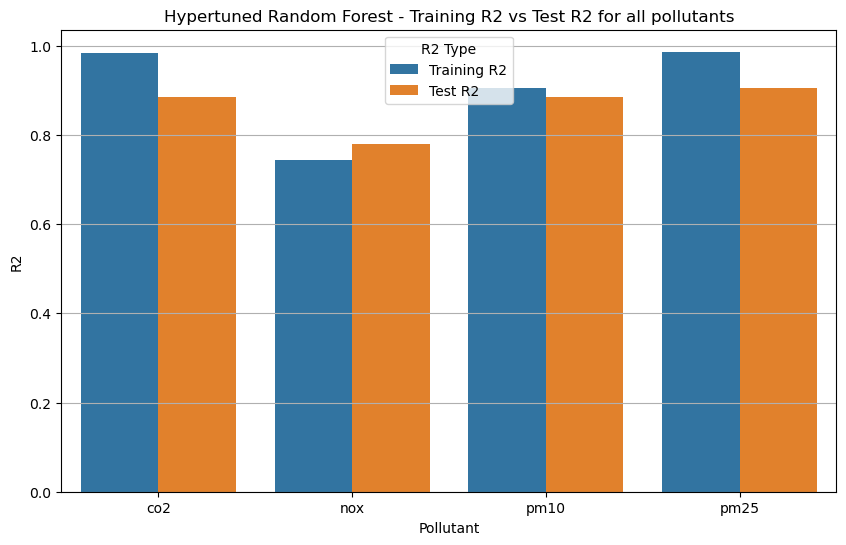

In [92]:
# Plot test vs train (R2 score)
r2_scores = test_train_evaluation_df[['Pollutant', 'Training R2', 'Test R2']]

# Transform dataframe for plotting
r2_scores_melted = pd.melt(
    r2_scores,
    id_vars='Pollutant',
    value_vars=['Training R2', 'Test R2'],
    var_name='R2 Type',
    value_name='R2'
)

# Creating the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=r2_scores_melted, x='Pollutant', y='R2', hue='R2 Type')

# Adding titles and labels
plt.title('Hypertuned Random Forest - Training R2 vs Test R2 for all pollutants')
plt.xlabel('Pollutant')
plt.ylabel('R2')
plt.legend(title='R2 Type')
plt.grid(axis='y')

# Show the plot
plt.show()

In [93]:
# Display table of Test vs. Train MAE scores
test_train_evaluation_df[['Pollutant', 'Training MAE', 'Test MAE']]

,Pollutant,Training MAE,Test MAE
0,co2,0.647260,2.662815
1,nox,0.015780,0.016371
2,pm10,0.000467,0.000638
3,pm25,0.000100,0.000345


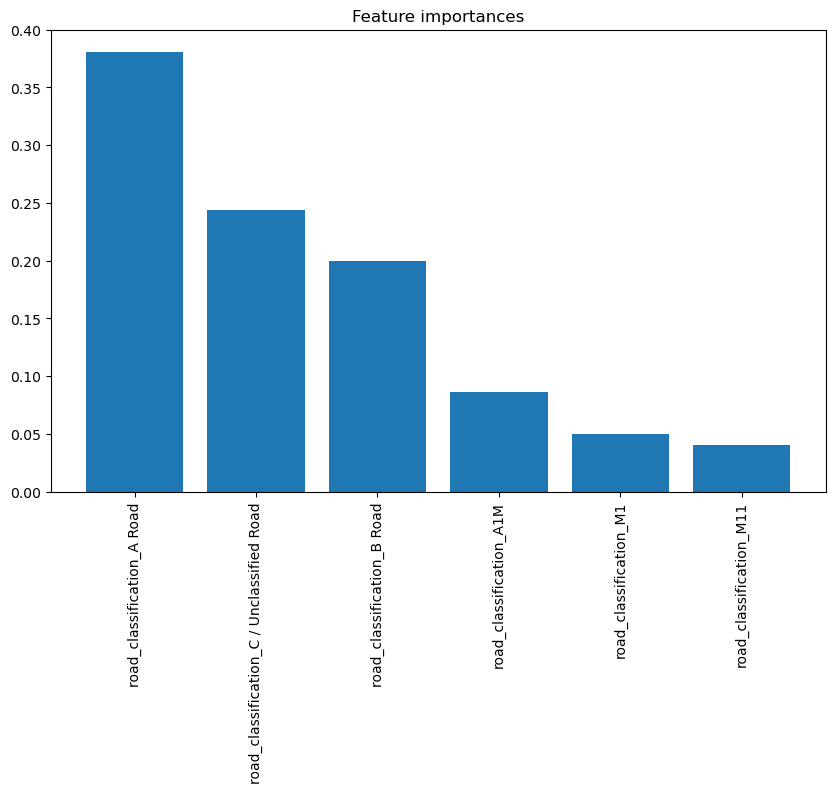

In [94]:
# Display Feature Importance

def plot_feature_importances(model, X_train, y_train, feature_names):
    # Access the best estimator from the RandomizedSearchCV object
    best_model = model.best_estimator_

    # Fit the best model
    rgr = best_model.fit(X_train, y_train)

    importances = rgr.feature_importances_
    indices = np.argsort(importances)[::-1]
    names = [feature_names[i] for i in indices]
    plt.figure(figsize=(10, 6))
    plt.title("Feature importances")
    plt.bar(range(X_train.shape[1]), importances[indices])
    plt.xticks(range(X_train.shape[1]), names, rotation=90)
    plt.show()

feature_names = tf_X_df.columns
plot_feature_importances(ran_reg_hyper_model, X_train, y_train, feature_names)


# Line chart

In [95]:
r2_scores.head()

,Pollutant,Training R2,Test R2
0,co2,0.982933,0.885840
1,nox,0.744872,0.779018
2,pm10,0.904975,0.885935
3,pm25,0.986817,0.905348


In [96]:
for x in r2_scores['Training R2']:
    print(x)

0.9829330018621104
0.7448716742145968
0.9049749226594654
0.9868170898561784


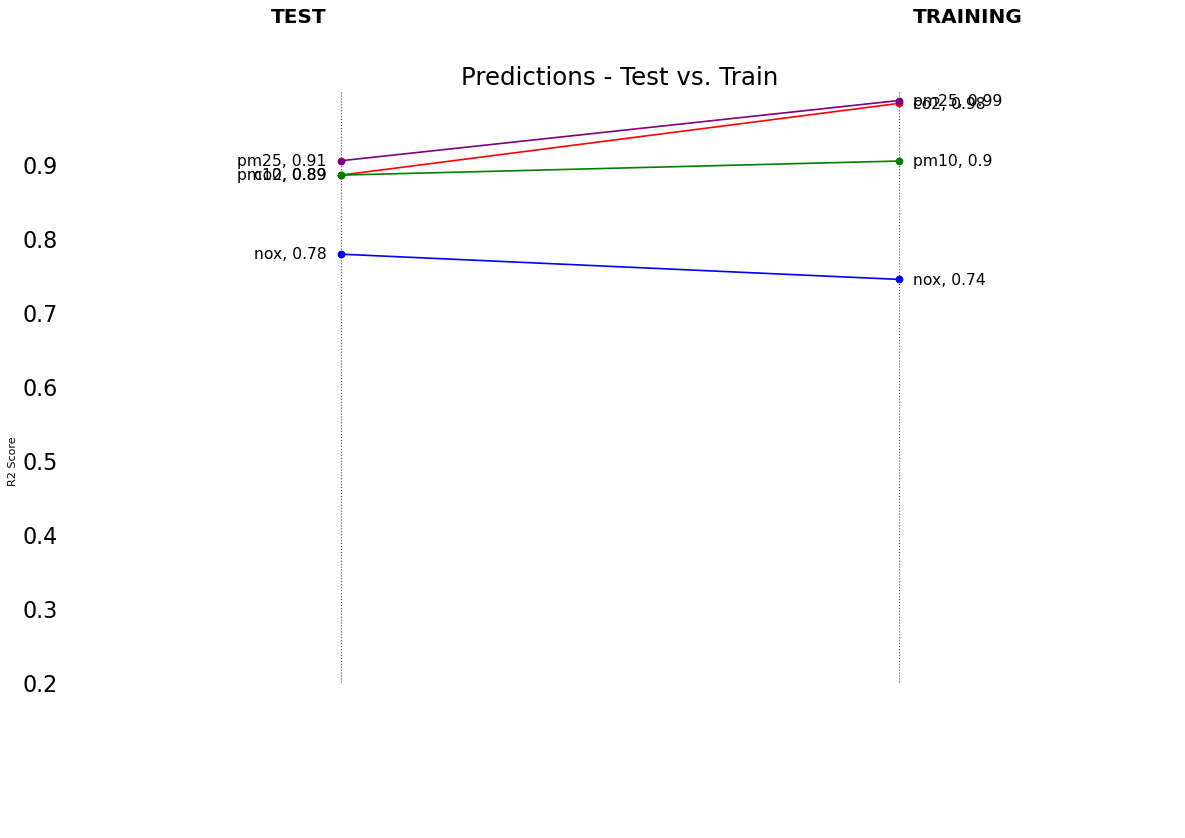

In [97]:
import matplotlib.lines as mlines

# draw line
# https://stackoverflow.com/questions/36470343/how-to-draw-a-line-with-matplotlib/36479941
def newline(p1, p2, colour='black'):
    ax = plt.gca()
    l = mlines.Line2D([p1[0], p2[0]], [p1[1], p2[1]], color=colour, marker='o', markersize=6)
    ax.add_line(l)
    return l

fig, ax = plt.subplots(1,1,figsize=(18,12), dpi= 80)

# Vertical Lines
ax.vlines(x=1, ymin=0.2, ymax=1, color='black', alpha=0.7, linewidth=1, linestyles='dotted')
ax.vlines(x=3, ymin=0.2, ymax=1, color='black', alpha=0.7, linewidth=1, linestyles='dotted')

# Points
ax.scatter(y=r2_scores['Test R2'], x=np.repeat(1, r2_scores.shape[0]), s=10, color='black', alpha=0.7)
ax.scatter(y=r2_scores['Training R2'], x=np.repeat(3, r2_scores.shape[0]), s=10, color='black', alpha=0.7)

# Colours for each line
colours = ['red', 'blue', 'green', 'purple']

# Line Segments and Annotation
for p1, p2, c, colour in zip(r2_scores['Test R2'], r2_scores['Training R2'], r2_scores['Pollutant'], colours):
    newline([1,p1], [3,p2], colour)
    ax.text(1-0.05, p1, c + ', ' + str(round(p1,2)), horizontalalignment='right', verticalalignment='center', fontdict={'size':14})
    ax.text(3+0.05, p2, c + ', ' + str(round(p2,2)), horizontalalignment='left', verticalalignment='center', fontdict={'size':14})

# 'Training' and 'Test' Annotations
ax.text(1-0.05, 1.1, 'TEST', horizontalalignment='right', verticalalignment='center', fontdict={'size':18, 'weight':700})
ax.text(3+0.05, 1.1, 'TRAINING', horizontalalignment='left', verticalalignment='center', fontdict={'size':18, 'weight':700})

# Decoration
ax.set_title("Predictions - Test vs. Train", fontdict={'size':22})
ax.set(xlim=(0,4), ylim=(0,1), ylabel='R2 Score')
ax.set_xticks([1,3])
ax.set_yticks([1,1])
ax.set_xticklabels(["Training", "Test"])
plt.yticks(np.arange(0.2, 1,0.1), fontsize=20)

ax.tick_params(axis='both', which='both', length=0)
ax.set_xticks([])


# Lighten borders
plt.gca().spines["top"].set_alpha(.0)
plt.gca().spines["bottom"].set_alpha(.0)
plt.gca().spines["right"].set_alpha(.0)
plt.gca().spines["left"].set_alpha(.0)
plt.show()